In [5]:
import pandas as pd
import numpy as np

In [6]:
products = pd.read_csv("products.csv")
product_category = pd.read_csv("productcategory.csv")
product_subcategory = pd.read_csv("productsubcategory.csv")

In [ ]:
# Porcentaje de datos faltantes por columna
products.isna().mean()

ProductID                0.000000
Name                     0.000000
ProductNumber            0.000000
MakeFlag                 0.000000
FinishedGoodsFlag        0.000000
Color                    0.492063
SafetyStockLevel         0.000000
ReorderPoint             0.000000
StandardCost             0.000000
ListPrice                0.000000
Size                     0.581349
SizeUnitMeasureCode      0.650794
WeightUnitMeasureCode    0.593254
Weight                   0.593254
DaysToManufacture        0.000000
ProductLine              0.448413
Class                    0.509921
Style                    0.581349
ProductSubcategoryID     0.414683
ProductModelID           0.414683
SellStartDate            0.000000
SellEndDate              0.805556
DiscontinuedDate         1.000000
rowguid                  0.000000
ModifiedDate             0.000000
dtype: float64

<Axes: xlabel='Weight', ylabel='Count'>

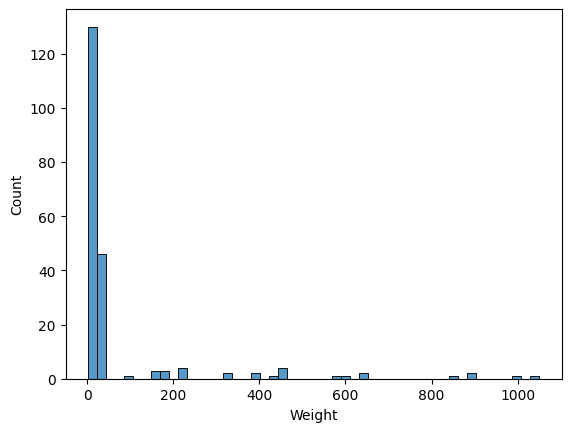

In [9]:
import seaborn as sns
sns.histplot(products["Weight"], bins=50)

In [12]:
products["weight_clean"] = np.where(products["Weight"].isnull(),0, products["Weight"])
products["weight_clean"].isna().mean()

np.float64(0.0)

In [14]:
products["color_clean"] = np.where(products["Color"].isnull(),"sin_color", products["Color"])

In [24]:
df_final = (
    products
    .merge(
        product_subcategory
        .rename(
            columns = {
                "Name":"subcategory_name"
                }
                )
        .drop(columns = ["ModifiedDate","rowguid"]), 
                on = "ProductSubcategoryID", 
                how ="left"
                )               
    .merge(
        product_category
        .rename(
            columns = {
                "Name":"category_name"
                }
                )
        .drop(columns = ["ModifiedDate","rowguid"]), 
                on = "ProductCategoryID", 
                how ="left"
    )
)

In [ ]:
def suma(numero_1 : int, numero_2 : int) -> int:
    '''Función que suma dos números enteros.'''    
    return numero_1 + numero_2

,ProductID,Name,ProductNumber,MakeFlag,FinishedGoodsFlag,Color,SafetyStockLevel,ReorderPoint,StandardCost,ListPrice,...,SellStartDate,SellEndDate,DiscontinuedDate,rowguid,ModifiedDate,weight_clean,color_clean,ProductCategoryID,subcategory_name,category_name
0,1,Adjustable Race,AR-5381,0,0,NaN,1000,750,0.0000,0.00,...,1998-06-01 00:00:00,NaN,NaN,...,2004-03-11 03:01:36,0.00,sin_color,NaN,NaN,NaN
1,2,Bearing Ball,BA-8327,0,0,NaN,1000,750,0.0000,0.00,...,1998-06-01 00:00:00,NaN,NaN,...,2004-03-11 03:01:36,0.00,sin_color,NaN,NaN,NaN
2,3,BB Ball Bearing,BE-2349,1,0,NaN,800,600,0.0000,0.00,...,1998-06-01 00:00:00,NaN,NaN,...,2004-03-11 03:01:36,0.00,sin_color,NaN,NaN,NaN
3,4,Headset Ball Bearings,BE-2908,0,0,NaN,800,600,0.0000,0.00,...,1998-06-01 00:00:00,NaN,NaN,...,2004-03-11 03:01:36,0.00,sin_color,NaN,NaN,NaN
4,316,Blade,BL-2036,1,0,NaN,800,600,0.0000,0.00,...,1998-06-01 00:00:00,NaN,NaN,...,2004-03-11 03:01:36,0.00,sin_color,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,995,ML Bottom Bracket,BB-8107,1,1,NaN,500,375,44.9506,101.24,...,2003-07-01 00:00:00,NaN,NaN,...,2004-03-11 03:01:36,168.00,sin_color,2.0,Bottom Brackets,Components
500,996,HL Bottom Bracket,BB-9108,1,1,NaN,500,375,53.9416,121.49,...,2003-07-01 00:00:00,NaN,NaN,...,2004-03-11 03:01:36,170.00,sin_color,2.0,Bottom Brackets,Components
501,997,"Road-750 Black, 44",BK-R19B-44,1,1,Black,100,75,343.6496,539.99,...,2003-07-01 00:00:00,NaN,NaN,...,2004-03-11 03:01:36,19.77,Black,1.0,Road Bikes,Bikes
502,998,"Road-750 Black, 48",BK-R19B-48,1,1,Black,100,75,343.6496,539.99,...,2003-07-01 00:00:00,NaN,NaN,...,2004-03-11 03:01:36,20.13,Black,1.0,Road Bikes,Bikes
